In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, utils, datasets
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
import scipy.io as sio
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("We're using =>", device)

We're using => cuda


In [3]:
train_transforms =  transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])

In [4]:
class dataset(torch.utils.data.Dataset):
    def __init__(self, filepath, transform=None):
        self.filepath = filepath
        self.transform = transform
        

    def __len__(self):
        self.filelength = len(os.listdir(self.filepath))
        return self.filelength
    

    def __getitem__(self,idx):
        img_path = os.listdir(self.filepath)[idx]
        mat_contents = sio.loadmat(os.path.join(self.filepath,img_path))

        
        signal_img = torch.from_numpy(mat_contents['correlated_FFT']).unsqueeze(0)
#         img_transformed = self.transform(img)
        
        label = mat_contents['Waveform'][0]
        if label == 'FiltBPSK':
            label=0
        elif label == 'FSK':
            label=1
            
        return signal_img,label

In [5]:
tempDatasetTrain = dataset("SignalFiles/train")
tempDatasetVal = dataset("SignalFiles/val")
tempDatasetTest = dataset("SignalFiles/test")


In [6]:
train_loader = torch.utils.data.DataLoader(dataset = tempDatasetTrain, batch_size=16, shuffle=True )
test_loader = torch.utils.data.DataLoader(dataset = tempDatasetTest, batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset = tempDatasetVal, batch_size=16, shuffle=True)

In [7]:
tempDatasetTrain[0][0].shape

torch.Size([1, 256, 256])

In [8]:
class Cnn(nn.Module):
    def __init__(self):
        super(Cnn,self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3, padding=0,stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(16,32, kernel_size=3, padding=0, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
            )
        
        self.layer3 = nn.Sequential(
            nn.Conv2d(32,64, kernel_size=3, padding=0, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        
        self.fc1 = nn.Linear(3*3*64,10)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(10,2)
        self.relu = nn.ReLU()
        
        
    def forward(self,x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.view(out.size(0),-1)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [9]:
model = Cnn().to(device)
model.train()

Cnn(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=576, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=10, out_features=2, bias=True)
  (re

In [10]:
optimizer = optim.Adam(params = model.parameters(),lr=0.001)
criterion = nn.CrossEntropyLoss()

In [11]:
epochs = 15
trainAccuracy = []
testAccuracy = []
valAccuracy = []

for epoch in range(epochs):
    epoch_loss = 0
    epoch_accuracy = 0
    
    for data, label in train_loader:
        data = data.to(device)
        label = label.to(device)
        
        output = model(data)
        loss = criterion(output, label)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        acc = ((output.argmax(dim=1) == label).float().mean())
        epoch_accuracy += acc/len(train_loader)
        epoch_loss += loss/len(train_loader)
        
    print('Epoch : {}, train accuracy : {}, train loss : {}'.format(epoch+1, epoch_accuracy,epoch_loss))
    trainAccuracy.append(epoch_accuracy)
    
    
    with torch.no_grad():
        epoch_val_accuracy=0
        epoch_val_loss =0
        for data, label in val_loader:
            data = data.to(device)
            label = label.to(device)
            
            val_output = model(data)
            val_loss = criterion(val_output,label)
            
            
            acc = ((val_output.argmax(dim=1) == label).float().mean())
            epoch_val_accuracy += acc/ len(val_loader)
            epoch_val_loss += val_loss/ len(val_loader)
            
        epoch_test_accuracy=0
        epoch_test_loss =0
            
        for data, label in test_loader:
            data = data.to(device)
            label = label.to(device)
            
            test_output = model(data)
            test_loss = criterion(test_output,label)
            
            
            acc = ((test_output.argmax(dim=1) == label).float().mean())
            epoch_test_accuracy += acc/ len(test_loader)
            epoch_test_loss += test_loss/ len(test_loader)
            
        print('Epoch : {}, val_accuracy : {}, val_loss : {}'.format(epoch+1, epoch_val_accuracy,epoch_val_loss))
        print('Epoch : {}, test_accuracy : {}, test_loss : {}'.format(epoch+1, epoch_test_accuracy,epoch_test_loss))
        testAccuracy.append(epoch_test_accuracy)
        valAccuracy.append(epoch_val_accuracy)

Epoch : 1, train accuracy : 0.8797904253005981, train loss : 0.2736673653125763
Epoch : 1, val_accuracy : 0.9498699903488159, val_loss : 0.13410262763500214
Epoch : 1, test_accuracy : 0.9485679864883423, test_loss : 0.13277937471866608
Epoch : 2, train accuracy : 0.9573167562484741, train loss : 0.11510144174098969
Epoch : 2, val_accuracy : 0.9570314288139343, val_loss : 0.10573428869247437
Epoch : 2, test_accuracy : 0.9579430222511292, test_loss : 0.10442780703306198
Epoch : 3, train accuracy : 0.9662446975708008, train loss : 0.08879101276397705
Epoch : 3, val_accuracy : 0.9672312140464783, val_loss : 0.08609191328287125
Epoch : 3, test_accuracy : 0.9670577049255371, test_loss : 0.08590873330831528
Epoch : 4, train accuracy : 0.9727780222892761, train loss : 0.07615023106336594
Epoch : 4, val_accuracy : 0.9652780890464783, val_loss : 0.09413284808397293
Epoch : 4, test_accuracy : 0.9648442268371582, test_loss : 0.0998333990573883
Epoch : 5, train accuracy : 0.9784395098686218, train 

In [ ]:
import matplotlib.pyplot as plt

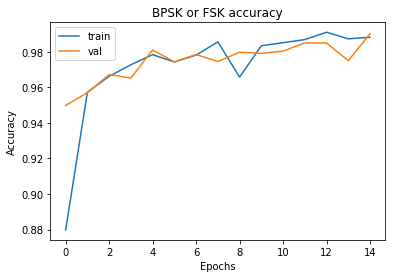

In [17]:
iterations = [x for x in range(15)]
plt.plot(iterations,trainAccuracy, label='train')
plt.plot(iterations,valAccuracy, label='val')
plt.legend()
plt.title('BPSK or FSK accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()